In [24]:
import pandas as pd
import mysql.connector

# Connexion à la base MySQL
conn = mysql.connector.connect(host="localhost", user="root", password="", database="ecommerce_data")

# Chargement dans un DataFrame pandas
df = pd.read_sql("SELECT * FROM shopify_products_variants", conn)

# Fermeture de la connexion
conn.close()

# Prévisualiser les données
df.head()


/tmp/ipykernel_415161/1968399219.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM shopify_products_variants", conn)


,id,product_id,title,handle,description,vendor,product_type,tags,published_at,created_at,...,variant_created_at,variant_updated_at,variant_featured_image_url,variant_featured_image_width,variant_featured_image_height,product_main_image_url,product_main_image_width,product_main_image_height,option_color,option_size
0,25,7942975455266,Thomas & Friends™ Tie Navy,thomas-the-tank-engine-tie-navy,Product Details Woven club-style necktie featu...,Rowing Blazers x Thomas & Friends™,Ties,"[""Shop All"", ""TH25""]",2025-05-20 11:56:45,2025-04-08 10:10:21,...,2025-04-08 10:10:21,2025-05-26 11:03:12,https://cdn.shopify.com/s/files/1/1770/6343/fi...,3000.0,3000.0,https://cdn.shopify.com/s/files/1/1770/6343/fi...,3000,3000,Navy,OS
1,26,7942973915170,Kid's Cotton Thomas & Friends™ Sweater Blue,kids-cotton-thomas-the-tank-engine-sweater-blue,Product Details Children’s cotton crewneck swe...,Rowing Blazers x Thomas & Friends™,Sweaters,"[""Shop All"", ""TH25""]",2025-05-20 11:56:44,2025-04-08 10:08:12,...,2025-04-08 10:08:12,2025-05-26 11:03:12,https://cdn.shopify.com/s/files/1/1770/6343/fi...,3000.0,3000.0,https://cdn.shopify.com/s/files/1/1770/6343/fi...,3000,3000,Blue,2-3
2,27,7942973915170,Kid's Cotton Thomas & Friends™ Sweater Blue,kids-cotton-thomas-the-tank-engine-sweater-blue,Product Details Children’s cotton crewneck swe...,Rowing Blazers x Thomas & Friends™,Sweaters,"[""Shop All"", ""TH25""]",2025-05-20 11:56:44,2025-04-08 10:08:12,...,2025-04-08 10:08:12,2025-05-26 11:03:12,https://cdn.shopify.com/s/files/1/1770/6343/fi...,3000.0,3000.0,https://cdn.shopify.com/s/files/1/1770/6343/fi...,3000,3000,Blue,4-5
3,28,7942973915170,Kid's Cotton Thomas & Friends™ Sweater Blue,kids-cotton-thomas-the-tank-engine-sweater-blue,Product Details Children’s cotton crewneck swe...,Rowing Blazers x Thomas & Friends™,Sweaters,"[""Shop All"", ""TH25""]",2025-05-20 11:56:44,2025-04-08 10:08:12,...,2025-04-08 10:08:12,2025-05-26 11:03:12,https://cdn.shopify.com/s/files/1/1770/6343/fi...,3000.0,3000.0,https://cdn.shopify.com/s/files/1/1770/6343/fi...,3000,3000,Blue,6-7
4,29,7942973915170,Kid's Cotton Thomas & Friends™ Sweater Blue,kids-cotton-thomas-the-tank-engine-sweater-blue,Product Details Children’s cotton crewneck swe...,Rowing Blazers x Thomas & Friends™,Sweaters,"[""Shop All"", ""TH25""]",2025-05-20 11:56:44,2025-04-08 10:08:12,...,2025-04-08 10:08:12,2025-05-26 11:03:12,https://cdn.shopify.com/s/files/1/1770/6343/fi...,3000.0,3000.0,https://cdn.shopify.com/s/files/1/1770/6343/fi...,3000,3000,Blue,8


In [25]:
from sklearn.preprocessing import MinMaxScaler

# Sélection des critères pertinents
features = ['price', 'available', 'grams']
df_features = df[features]

# Normalisation (Min-Max Scaling)
scaler = MinMaxScaler()
normalized_features = scaler.fit_transform(df_features)

df_normalized = pd.DataFrame(normalized_features, columns=features)

# Appliquer des pondérations
weights = {
    'price': 0.4,
    'available': 0.3,
    'grams': 0.3
}

# Calcul du score global pondéré
df_normalized['score'] = ( df_normalized['price'] * weights['price'] + df_normalized['available'] * weights['available'] + df_normalized['grams'] * weights['grams'] )

# Ajouter les scores au DataFrame initial
df['score'] = df_normalized['score']


In [26]:
df_sorted = df.sort_values(by='score', ascending=False)

In [27]:
df_unique = df_sorted.drop_duplicates(subset=['title'], keep='first').reset_index(drop=True)

In [28]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

features = ['price', 'available', 'grams']

# Normalize the features again for clustering
scaler = MinMaxScaler()
normalized_features = scaler.fit_transform(df_unique[features])

kmeans = KMeans(n_clusters=3, random_state=42)
df_unique['cluster'] = kmeans.fit_predict(normalized_features)


In [29]:
K = 10
top_k_unique_products = df_unique.head(K)

print(top_k_unique_products[['title', 'cluster', 'score']])


                                      title  cluster     score
0                     American Pillar Thuja        2  0.688444
1                Happy Monday Colombia 10lb        2  0.627257
2                  Bloodgood Japanese Maple        2  0.611783
3                   Cold Hardy Avocado Tree        2  0.586230
4                 Bonfire Patio Peach Plant        2  0.584526
5      English Laurel Topiary (Single Ball)        2  0.581119
6                Cold Hardy Red Pomegranate        2  0.560676
7     Green Mountain Topiary Boxwood (Ball)        2  0.557269
8  Thunderstruck™ Rumblin' Red™ Crapemyrtle        2  0.557269
9               Texas Pink Pomegranate Tree        2  0.557269


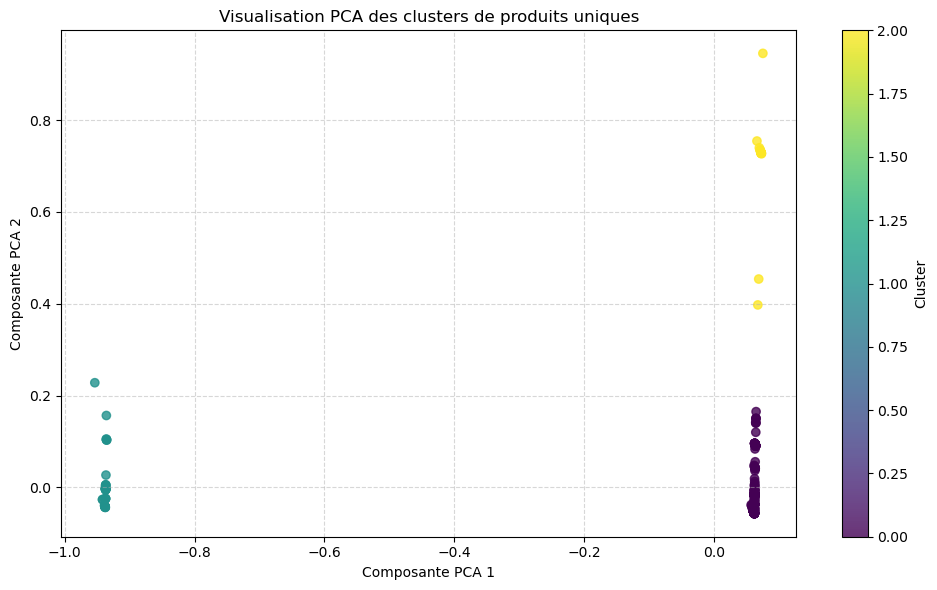

In [30]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler

# Normaliser les données pour PCA (sur les produits uniques déjà sélectionnés)
features = ['price', 'available', 'grams']
scaler = MinMaxScaler()
normalized_features = scaler.fit_transform(df_unique[features])

# PCA avec 2 composantes sur les données uniques normalisées
pca = PCA(n_components=2)
reduced_data = pca.fit_transform(normalized_features)

# Visualisation claire et précise des clusters avec PCA
plt.figure(figsize=(10, 6))
scatter = plt.scatter(reduced_data[:, 0], reduced_data[:, 1],
                      c=df_unique['cluster'], cmap='viridis', alpha=0.8)

plt.xlabel('Composante PCA 1')
plt.ylabel('Composante PCA 2')
plt.title('Visualisation PCA des clusters de produits uniques')

# Légende claire pour les clusters
plt.colorbar(scatter, label='Cluster')

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
